In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

In [27]:
base_path = Path.cwd()
data_dir = base_path.parent/"data"/"02_cleaned_data"/"cleaned_data.csv"
batting_dir = base_path.parent/"data"/"02_cleaned_data"/"batting_stats.csv"
bowling_dir = base_path.parent/"data"/"02_cleaned_data"/"batting_stats.csv"
plot_dir = base_path.parent/"docs"/"plots"

In [32]:
source_df = pd.read_csv(data_dir)

In [ ]:
middle_overs= source_df[(source_df['over'] >=6) & (source_df['over']<16) ]

In [75]:
# Calculate the runs and balls for batter
md_batting_stats = middle_overs.groupby(['batting_team','batter']).agg(
    {
        'runs_bat':'sum',
        'ball':'count'
    }
).reset_index()

md_batting_stats['strike_rate'] = (md_batting_stats['runs_bat'] / md_batting_stats['ball']) * 100

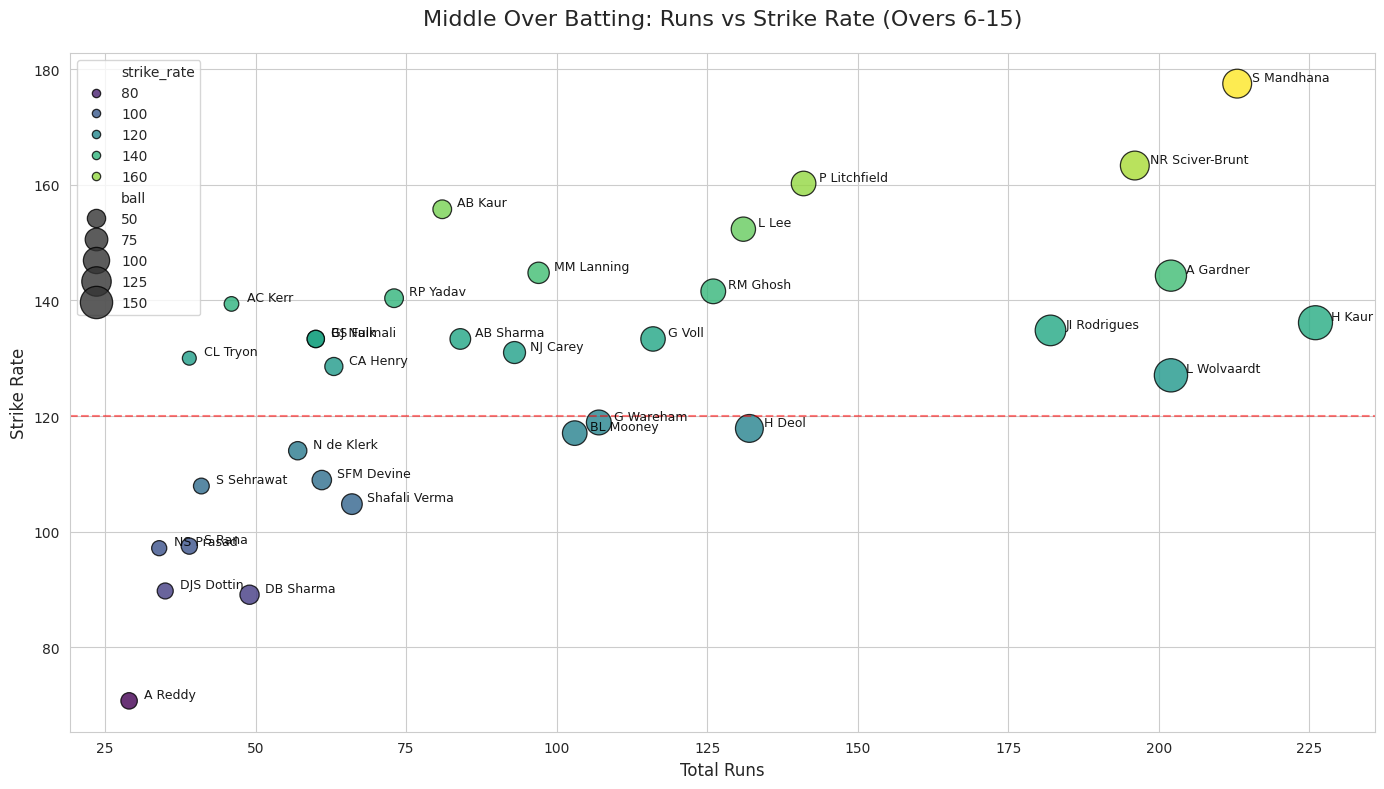

In [92]:
# Visualizing middle overs batting
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

top_middle_order_batter = md_batting_stats[md_batting_stats['ball'] >= 30]

scatter = sns.scatterplot(
    data=top_middle_order_batter,
    x='runs_bat',
    y='strike_rate',
    size='ball',
    hue='strike_rate', 
    palette='viridis',
    sizes=(100, 600),
    edgecolor='black',
    alpha=0.8
)


for i in range(top_middle_order_batter.shape[0]):
    plt.text(
        x=top_middle_order_batter.iloc[i]['runs_bat'] + 2.5, 
        y=top_middle_order_batter.iloc[i]['strike_rate']+1.1, 
        s=top_middle_order_batter.iloc[i]['batter'], 
        fontsize=9,
        alpha=0.9,
        ha='left',              
        va='center',            
        color='black'
    )


plt.title('Middle Over Batting: Runs vs Strike Rate (Overs 6-15)', fontsize=16, pad=20)
plt.axhline(120, ls='--', color='red', alpha=0.5, label='Avg SR Benchmark')
plt.xlabel('Total Runs', fontsize=12)
plt.ylabel('Strike Rate', fontsize=12)


plt.tight_layout()
plt.savefig(rf'{plot_dir}/middle_overs_batting_stats')
plt.show()

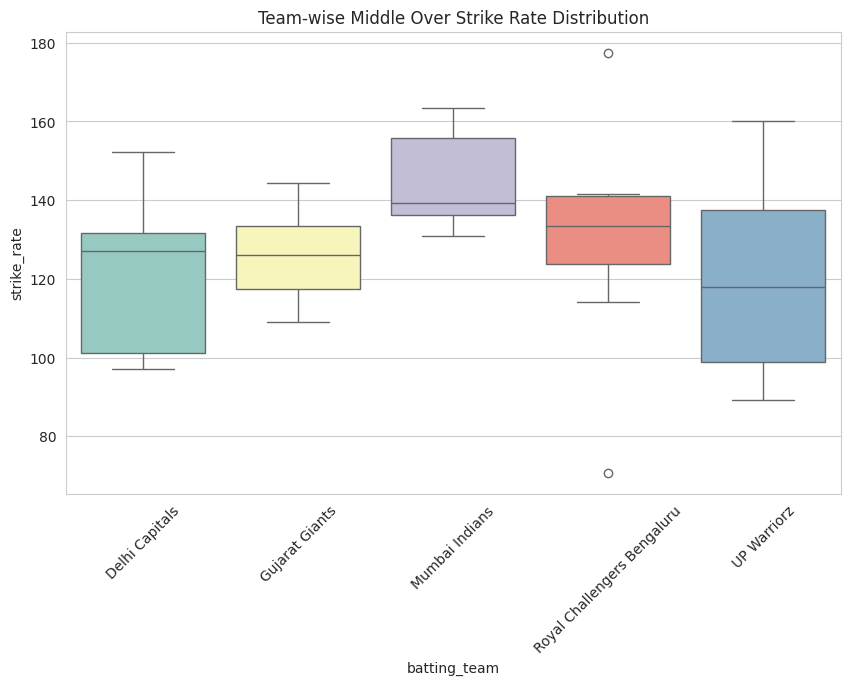

In [91]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=top_middle_order_batter,
    x='batting_team',
    y='strike_rate',
    hue='batting_team',
    legend=False,
    palette='Set3'
)

plt.xticks(rotation=45)
plt.title('Team-wise Middle Over Strike Rate Distribution')
plt.savefig(rf'{plot_dir}/middle_overs_batting_team_stats')
plt.show()

In [67]:
# Calculate middle overs bowling stats
md_bowling_stats  =source_df[(source_df['over']>=6) & (source_df['over'] < 16)].copy()

bowler_wicket_type = ['caught','stumped','bowled','lbw','caught and bowled','hit wicket']
md_bowling_stats['is_bowler_wicket'] = md_bowling_stats['wicket_kind'].fillna(' ').isin(bowler_wicket_type)

md_bowler_stats = md_bowling_stats.groupby(['bowling_team','bowler']).agg(
    {
        'runs_bat':'sum',
        'is_wide':'sum',
        'is_noball':'sum',
        'ball':'sum',
        'is_bowler_wicket': 'sum',
        'is_wicket':'sum' 
    }
).reset_index()
md_bowler_stats.rename(columns={'is_bowler_wicket': 'wickets','is_wicket':'team_wickets'}, inplace=True)

md_bowler_stats['total_runs'] = md_bowler_stats['runs_bat'] + md_bowler_stats['is_noball'] + md_bowler_stats['is_wide']

md_bowler_stats['economy'] = np.multiply(
    np.divide(md_bowler_stats['total_runs'], md_bowler_stats['ball']), 
    6
)
md_bowler_stats['bowling_sr'] = np.where(
    md_bowler_stats['wickets'] > 0,
    np.divide(md_bowler_stats['ball'], md_bowler_stats['wickets']),
    np.nan 
)

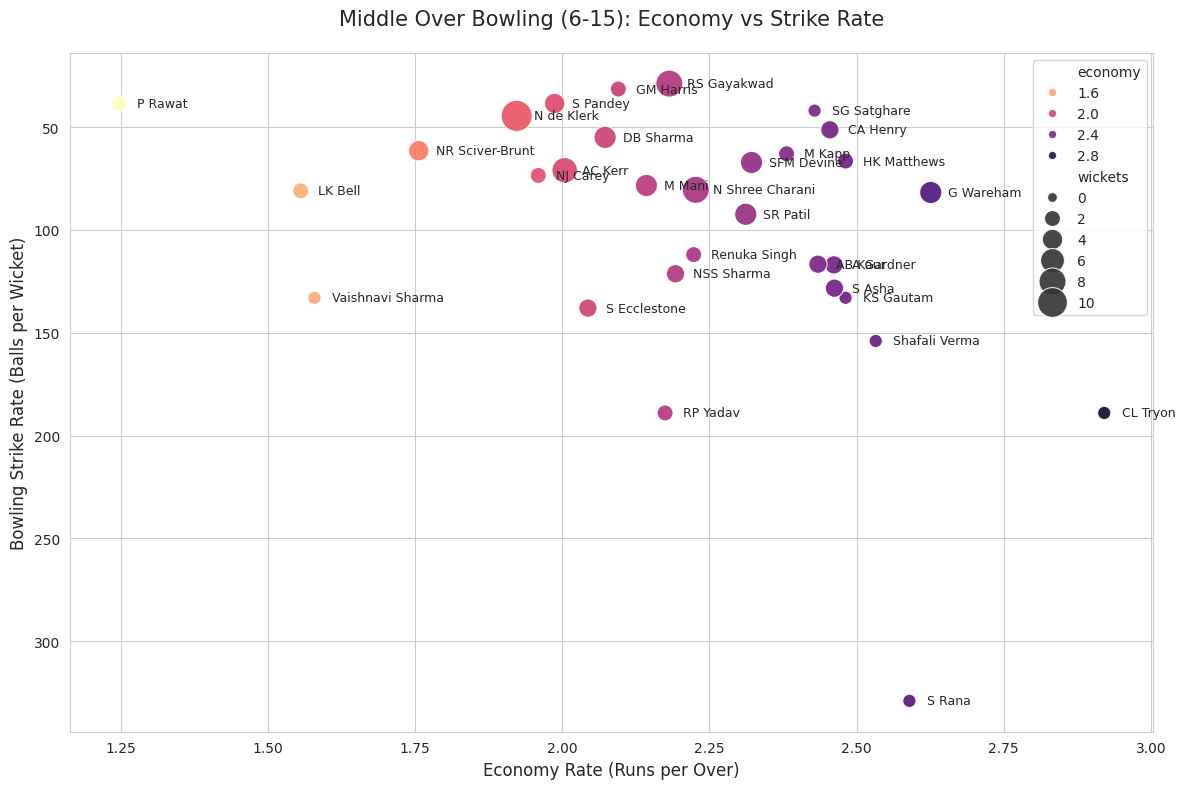

In [90]:
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

top_md_bowlers = md_bowler_stats[md_bowler_stats['ball'] >= 24].copy()

scatter = sns.scatterplot(
    data=top_md_bowlers,
    x='economy',
    y='bowling_sr',
    size='wickets',
    hue='economy',
    palette='magma_r',     
    sizes=(50, 500),
    alpha=0.9
)


for index, row in top_md_bowlers.iterrows():
    if row['economy'] < 7.0 or row['wickets'] >= 2:
        plt.text(
            x=row['economy'] + 0.03, 
            y=row['bowling_sr'], 
            s=row['bowler'], 
            fontsize=9,
            va='center'
        )


plt.title('Middle Over Bowling (6-15): Economy vs Strike Rate', fontsize=15, pad=20)
plt.xlabel('Economy Rate (Runs per Over)', fontsize=12)
plt.ylabel('Bowling Strike Rate (Balls per Wicket)', fontsize=12)

plt.gca().invert_yaxis() 
plt.tight_layout()
plt.savefig(rf'{plot_dir}/middle_overs_bowling_stats')
plt.show()

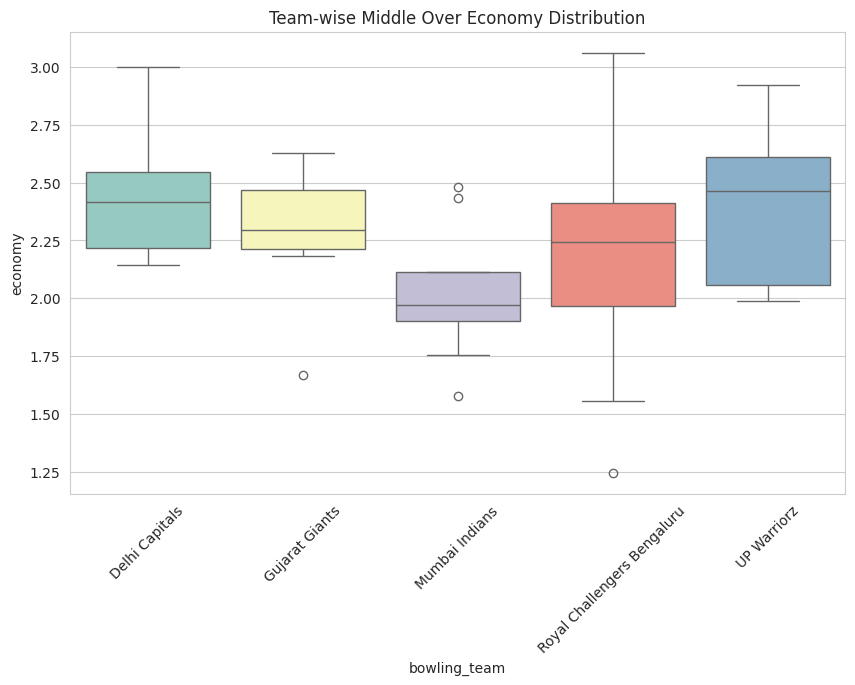

In [93]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=top_md_bowlers,
    x='bowling_team',
    y='economy',
    hue='bowling_team',
    legend=False,
    palette='Set3'
)

plt.xticks(rotation=45)
plt.title('Team-wise Middle Over Economy Distribution')
plt.savefig(rf'{plot_dir}/middle_overs_bowling_team_stats')
plt.show()